In [1]:
import os
import re
import random
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
from tqdm import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)


cuda


In [2]:
from pathlib import Path

dataset_root = Path(
    "/kaggle/input/datasets/sabahesaraki/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT"
)

print("Dataset Loaded From:", dataset_root)

# quick sanity check
print("Classes:", list(dataset_root.iterdir()))


Dataset Loaded From: /kaggle/input/datasets/sabahesaraki/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT
Classes: [PosixPath('/kaggle/input/datasets/sabahesaraki/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/benign'), PosixPath('/kaggle/input/datasets/sabahesaraki/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/normal'), PosixPath('/kaggle/input/datasets/sabahesaraki/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT/malignant')]


In [3]:
rows = []
classes = ['benign','malignant','normal']

for cls in classes:
    for img_path in (dataset_root/cls).glob("*.png"):
        if "_mask" in img_path.name:
            continue
        rows.append({
            "image_path": str(img_path),
            "class": cls
        })

df = pd.DataFrame(rows)
df["class_idx"] = df["class"].map({c:i for i,c in enumerate(classes)})
df["id"] = df["image_path"].apply(lambda x: Path(x).stem)

df.head(100)


,image_path,class,class_idx,id
0,/kaggle/input/datasets/sabahesaraki/breast-ult...,benign,0,benign (2)
1,/kaggle/input/datasets/sabahesaraki/breast-ult...,benign,0,benign (285)
2,/kaggle/input/datasets/sabahesaraki/breast-ult...,benign,0,benign (300)
3,/kaggle/input/datasets/sabahesaraki/breast-ult...,benign,0,benign (390)
4,/kaggle/input/datasets/sabahesaraki/breast-ult...,benign,0,benign (357)
...,...,...,...,...
95,/kaggle/input/datasets/sabahesaraki/breast-ult...,benign,0,benign (193)
96,/kaggle/input/datasets/sabahesaraki/breast-ult...,benign,0,benign (16)
97,/kaggle/input/datasets/sabahesaraki/breast-ult...,benign,0,benign (410)
98,/kaggle/input/datasets/sabahesaraki/breast-ult...,benign,0,benign (299)


In [4]:
def infer_group(name):
    m = re.search(r'\((\d+)\)', name)
    if m:
        return name.split('(')[0] + "_" + m.group(1)
    return name.split('_')[0]

df["group"] = df["id"].apply(infer_group)

gss = GroupShuffleSplit(test_size=0.30, n_splits=1, random_state=SEED)
train_idx, temp_idx = next(gss.split(df, df["class_idx"], df["group"]))

temp = df.iloc[temp_idx]

gss2 = GroupShuffleSplit(test_size=0.5, n_splits=1, random_state=SEED)
val_idx, test_idx = next(gss2.split(temp, temp["class_idx"], temp["group"]))

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df = temp.iloc[val_idx].reset_index(drop=True)
test_df = temp.iloc[test_idx].reset_index(drop=True)

print(len(train_df), len(val_df), len(test_df))


546 117 117


In [5]:
def get_mean_std(paths, n=300):
    mean = np.zeros(3)
    sq = np.zeros(3)
    for i,p in enumerate(paths[:n]):
        img = np.array(Image.open(p).convert("RGB"))/255.0
        mean += img.mean(axis=(0,1))
        sq += (img**2).mean(axis=(0,1))
    mean/=n
    std = np.sqrt(sq/n - mean**2)
    return mean, std

mean, std = get_mean_std(train_df.image_path.tolist())
print(mean, std)


[0.33744072 0.33742213 0.33730497] [0.22255777 0.22255895 0.22251633]


In [6]:
IMG_SIZE = 224

train_tf = T.Compose([
    T.Resize((IMG_SIZE,IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(25),
    T.RandomAffine(0, scale=(0.9,1.1)),
    T.ColorJitter(0.2,0.2),
    T.ToTensor(),
    T.Normalize(mean,std)
])

val_tf = T.Compose([
    T.Resize((IMG_SIZE,IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean,std)
])


In [7]:
class BUSI(Dataset):
    def __init__(self, df, tf=None):
        self.df = df
        self.tf = tf
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(row.image_path).convert("RGB")
        if self.tf:
            img = self.tf(img)
        return img, int(row.class_idx)


In [8]:
train_loader = DataLoader(BUSI(train_df,train_tf), batch_size=16, shuffle=True)
val_loader   = DataLoader(BUSI(val_df,val_tf), batch_size=16)
test_loader  = DataLoader(BUSI(test_df,val_tf), batch_size=16)


In [9]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df.class_idx),
    y=train_df.class_idx
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print(class_weights)


tensor([0.6087, 1.2133, 1.8763], device='cuda:0')


In [10]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction="none")

    def forward(self, logits, targets):
        ce = self.ce(logits, targets)
        pt = torch.exp(-ce)
        loss = (1-pt)**self.gamma * ce
        if self.alpha is not None:
            at = self.alpha.gather(0, targets)
            loss = at * loss
        return loss.mean()

criterion = FocalLoss(alpha=class_weights, gamma=2)


In [13]:
model = models.resnet50(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 3)
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


In [14]:
best = 0

for epoch in range(12):
    model.train()
    preds, trues = [], []
    
    for x,y in tqdm(train_loader):
        x,y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out,y)
        loss.backward()
        optimizer.step()
        
        preds += out.argmax(1).cpu().tolist()
        trues += y.cpu().tolist()
    
    train_acc = accuracy_score(trues,preds)
    
    model.eval()
    preds, trues = [], []
    
    with torch.no_grad():
        for x,y in val_loader:
            x = x.to(device)
            out = model(x)
            preds += out.argmax(1).cpu().tolist()
            trues += y.tolist()
    
    val_acc = accuracy_score(trues,preds)
    
    print(f"Epoch {epoch+1} TrainAcc {train_acc:.3f} ValAcc {val_acc:.3f}")
    
    if val_acc > best:
        best = val_acc
        torch.save(model.state_dict(),"best.pth")


100%|██████████| 35/35 [00:13<00:00,  2.59it/s]


Epoch 1 TrainAcc 0.562 ValAcc 0.709


100%|██████████| 35/35 [00:10<00:00,  3.29it/s]


Epoch 2 TrainAcc 0.727 ValAcc 0.821


100%|██████████| 35/35 [00:09<00:00,  3.59it/s]


...

Epoch 10 TrainAcc 0.857 ValAcc 0.761


100%|██████████| 35/35 [00:09<00:00,  3.58it/s]


Epoch 11 TrainAcc 0.868 ValAcc 0.726


100%|██████████| 35/35 [00:09<00:00,  3.54it/s]


Epoch 12 TrainAcc 0.896 ValAcc 0.906


Accuracy: 0.8290598290598291
              precision    recall  f1-score   support

      benign       0.88      0.90      0.89        68
   malignant       0.81      0.69      0.75        32
      normal       0.67      0.82      0.74        17

    accuracy                           0.83       117
   macro avg       0.79      0.80      0.79       117
weighted avg       0.83      0.83      0.83       117



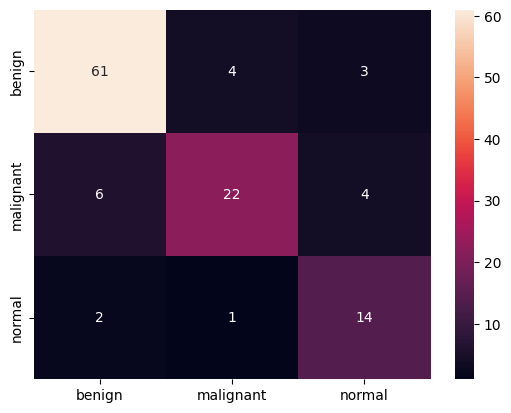

benign AUC: 0.9642857142857143
malignant AUC: 0.9356617647058824
normal AUC: 0.9729411764705882


In [15]:
model.load_state_dict(torch.load("best.pth"))
model.eval()

preds, trues, probs = [], [], []

with torch.no_grad():
    for x,y in test_loader:
        x = x.to(device)
        out = model(x)
        p = torch.softmax(out,1).cpu().numpy()
        
        probs.extend(p)
        preds.extend(out.argmax(1).cpu().tolist())
        trues.extend(y.tolist())

print("Accuracy:", accuracy_score(trues,preds))
print(classification_report(trues,preds,target_names=classes))

cm = confusion_matrix(trues,preds)

sns.heatmap(cm, annot=True, fmt="d", xticklabels=classes, yticklabels=classes)
plt.show()

y_bin = label_binarize(trues, classes=[0,1,2])
probs = np.array(probs)

for i,c in enumerate(classes):
    print(c,"AUC:", roc_auc_score(y_bin[:,i], probs[:,i]))
